# 🎬 Netflix Prize — Recommendation System
## Personalized Content Discovery · End-to-End Notebook

This single notebook covers the full pipeline:

| Section | Content |
|---------|---------|
| **1 · Setup** | Imports, config, data loading |
| **2 · EDA** | Rating distributions, user/movie patterns, sparsity, temporal trends |
| **3 · Preprocessing** | Train/test split, ID encoding |
| **4 · Model 1 — SVD** | Matrix Factorization via scikit-surprise |
| **5 · Model 2 — NeuMF** | Neural Collaborative Filtering via PyTorch (GPU) |
| **6 · Recommendations** | Top-10 generation for both models |
| **7 · Evaluation** | RMSE, MAP@10, success/failure analysis |
| **8 · Summary** | Comparison table, key insights |

> **Dataset:** [Kaggle Netflix Prize Data](https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data)


---
## Section 1 · Setup


In [ ]:
# Install dependencies (run once — uncomment)
# !pip install pandas numpy matplotlib seaborn scikit-surprise torch tqdm pyarrow


In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, gc, warnings, pickle, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from surprise import SVD, Reader, Dataset as SurpriseDataset

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('husl')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports complete')
print(f'   Device : {device}')
if device.type == 'cuda':
    print(f'   GPU    : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Matplotlib is building the font cache; this may take a moment.


✅ Imports complete
   Device : cpu


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────
# ⚙️  Data directory and output paths
DATA_DIR   = Path('.')              # Data files are in current directory
OUTPUT_DIR = Path('./results/outputs')
MODEL_DIR  = Path('./results/models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Sampling (reduce for faster iteration)
MIN_USER_RATINGS  = 50           # users with >= N ratings
MIN_MOVIE_RATINGS = 100          # movies with >= N ratings
MAX_RATINGS       = 2_000_000    # cap total ratings (memory safety)

# Train/test split
TEST_RATIO   = 0.2               # last 20% of each user's ratings → test

# SVD hyperparameters
SVD_FACTORS  = 100
SVD_EPOCHS   = 20
SVD_LR       = 0.005
SVD_REG      = 0.02

# NeuMF hyperparameters
NCF_EMBED_DIM  = 64
NCF_MLP_LAYERS = [256, 128, 64]
NCF_DROPOUT    = 0.2
NCF_LR         = 1e-3
NCF_WD         = 1e-5
NCF_BATCH      = 2048
NCF_EPOCHS     = 15

# Evaluation
TOP_K               = 10
RELEVANCE_THRESHOLD = 3.5        # rating >= 3.5 → relevant

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
print('✅ Config ready')
print(f'   Data dir: {DATA_DIR.absolute()}')
print(f'   Output dir: {OUTPUT_DIR.absolute()}')
print(f'   Model dir: {MODEL_DIR.absolute()}')

✅ Config ready
   Data dir: d:\open_project\netflix
   Output dir: d:\open_project\netflix\results\outputs
   Model dir: d:\open_project\netflix\results\models


In [3]:
# ── Parse Netflix Prize files ─────────────────────────────────────────────────
def parse_netflix_files(data_dir, filenames=None):
    '''Parse Netflix Prize .txt files.

    Format per file:
        MovieID:
        UserID,Rating,Date
        ...
    Returns DataFrame: movie_id | user_id | rating | date
    '''
    if filenames is None:
        filenames = [f'combined_data_{i}.txt' for i in range(1, 5)]
    records, cur_movie = [], None
    for fname in filenames:
        fpath = data_dir / fname
        if not fpath.exists():
            print(f'  ⚠️  {fname} not found — skipping.')
            continue
        print(f'  📂 Parsing {fname}…')
        with open(fpath, encoding='utf-8', errors='ignore') as f:
            for line in tqdm(f, desc=fname, mininterval=3, unit=' lines'):
                line = line.strip()
                if not line:
                    continue
                if line.endswith(':'):
                    cur_movie = int(line[:-1])
                elif cur_movie is not None:
                    p = line.split(',')
                    if len(p) == 3:
                        records.append((cur_movie, int(p[0]), int(p[1]), p[2].strip()))
    df = pd.DataFrame(records, columns=['movie_id','user_id','rating','date'])
    df['date'] = pd.to_datetime(df['date'])
    print(f'  ✅ Parsed {len(df):,} raw records')
    return df


def load_movies(data_dir):
    '''Load movie_titles.csv → DataFrame: movie_id | year | title'''
    fpath = data_dir / 'movie_titles.csv'
    if not fpath.exists():
        print('⚠️  movie_titles.csv not found.')
        return pd.DataFrame(columns=['movie_id','year','title'])
    movies = pd.read_csv(fpath, encoding='latin-1',
                         names=['movie_id','year','title'],
                         header=None, on_bad_lines='skip')
    movies['year']     = pd.to_numeric(movies['year'], errors='coerce')
    movies['movie_id'] = movies['movie_id'].astype(int)
    return movies


print('Loading data…')
df_raw    = parse_netflix_files(DATA_DIR)
movies_df = load_movies(DATA_DIR)
print(f'Movie catalogue: {len(movies_df):,} titles')


Loading data…
  📂 Parsing combined_data_1.txt…


combined_data_1.txt: 24058263 lines [00:51, 470167.95 lines/s]


  📂 Parsing combined_data_2.txt…


combined_data_2.txt: 26982302 lines [01:06, 405807.41 lines/s]


  📂 Parsing combined_data_3.txt…


combined_data_3.txt: 22605786 lines [01:01, 366401.60 lines/s]


  📂 Parsing combined_data_4.txt…


combined_data_4.txt: 26851926 lines [01:38, 273231.79 lines/s]


  ✅ Parsed 100,480,507 raw records
Movie catalogue: 17,434 titles


In [4]:
# ── Sampling ──────────────────────────────────────────────────────────────────
print('Applying sampling filters…')

user_counts  = df_raw['user_id'].value_counts()
active_users = user_counts[user_counts >= MIN_USER_RATINGS].index
df = df_raw[df_raw['user_id'].isin(active_users)].copy()
print(f'  User filter  (>={MIN_USER_RATINGS}): {len(df):,} rows | '
      f'{df["user_id"].nunique():,} users')

movie_counts   = df['movie_id'].value_counts()
popular_movies = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index
df = df[df['movie_id'].isin(popular_movies)].copy()
print(f'  Movie filter (>={MIN_MOVIE_RATINGS}): {len(df):,} rows | '
      f'{df["movie_id"].nunique():,} movies')

if len(df) > MAX_RATINGS:
    df = df.sample(n=MAX_RATINGS, random_state=RANDOM_STATE)
    print(f'  Sampled down to {MAX_RATINGS:,} ratings')

df = df.reset_index(drop=True)
del df_raw; gc.collect()
print(f'\n✅ Working dataset: {len(df):,} ratings | '
      f'{df["user_id"].nunique():,} users | {df["movie_id"].nunique():,} movies')


Applying sampling filters…
  User filter  (>=50): 96,449,656 rows | 327,204 users
  Movie filter (>=100): 96,354,837 rows | 16,600 movies
  Sampled down to 2,000,000 ratings

✅ Working dataset: 2,000,000 ratings | 300,281 users | 16,353 movies


---
## Section 2 · Exploratory Data Analysis


In [5]:
# ── Dataset overview ──────────────────────────────────────────────────────────
n_users  = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()
sparsity = 1 - len(df) / (n_users * n_movies)

print('DATASET OVERVIEW')
print(f'  Total ratings  : {len(df):>12,}')
print(f'  Unique users   : {n_users:>12,}')
print(f'  Unique movies  : {n_movies:>12,}')
print(f'  Date range     : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'  Rating range   : {df["rating"].min()} – {df["rating"].max()}')
print(f'  Mean ± Std     : {df["rating"].mean():.4f} ± {df["rating"].std():.4f}')
print(f'  Matrix density : {(1-sparsity)*100:.4f}%')
print(f'  Sparsity       : {sparsity*100:.4f}%')
df.head()


DATASET OVERVIEW
  Total ratings  :    2,000,000
  Unique users   :      300,281
  Unique movies  :       16,353
  Date range     : 1999-12-06 → 2005-12-31
  Rating range   : 1 – 5
  Mean ± Std     : 3.6018 ± 1.0812
  Matrix density : 0.0407%
  Sparsity       : 99.9593%


,movie_id,user_id,rating,date
0,11064,2169233,5,2004-01-17
1,1865,2016575,4,2004-12-29
2,13412,742733,5,2004-08-19
3,2348,1395543,3,2001-10-04
4,4761,1032704,3,2005-11-17


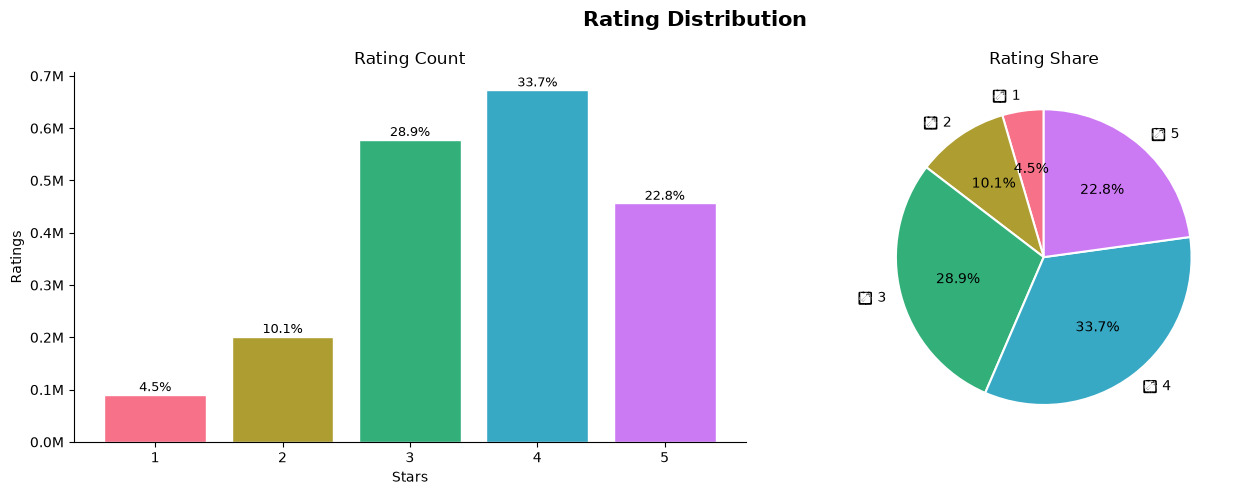

📌 Positive bias: 4★ & 5★ dominate — users tend to watch what they expect to enjoy.


In [6]:
# ── Rating distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts  = df['rating'].value_counts().sort_index()
palette = sns.color_palette('husl', 5)

axes[0].bar(counts.index, counts.values, color=palette, edgecolor='white')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e6:.1f}M'))
for x, y in zip(counts.index, counts.values):
    axes[0].text(x, y + max(counts)*0.01, f'{y/len(df)*100:.1f}%', ha='center', fontsize=9)
axes[0].set(title='Rating Count', xlabel='Stars', ylabel='Ratings')

axes[1].pie(counts.values, labels=[f'⭐ {r}' for r in counts.index],
            autopct='%1.1f%%', startangle=90, colors=palette,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Rating Share')

plt.suptitle('Rating Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Positive bias: 4★ & 5★ dominate — users tend to watch what they expect to enjoy.')


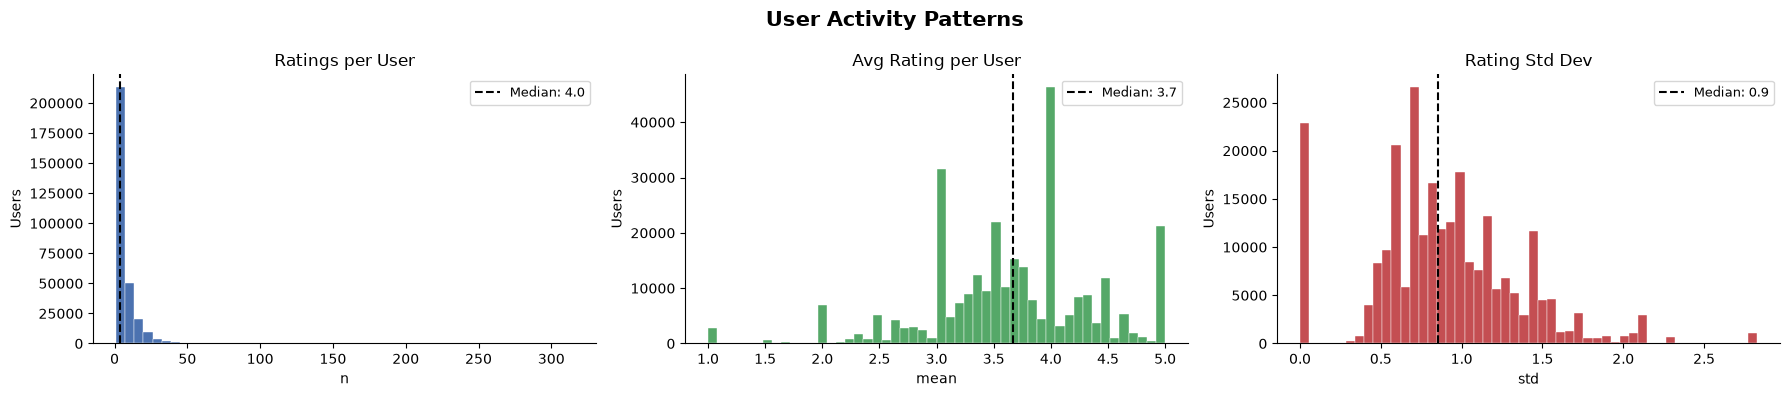


User Tier Breakdown:
                   users  avg_ratings  avg_score    pct
tier                                                   
Casual (<=100)    300232         6.64       3.66  100.0
Active (101-500)      49       148.53       2.76    0.0


In [7]:
# ── User activity patterns ────────────────────────────────────────────────────
user_stats = df.groupby('user_id').agg(
    n    = ('rating','count'),
    mean = ('rating','mean'),
    std  = ('rating','std')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, title, color in zip(
        axes,
        ['n',    'mean',               'std'],
        ['Ratings per User','Avg Rating per User','Rating Std Dev'],
        ['#4C72B0','#55A868','#C44E52']):
    ax.hist(user_stats[col].dropna(), bins=50, color=color,
            edgecolor='white', linewidth=0.3)
    med = user_stats[col].median()
    ax.axvline(med, color='black', ls='--', label=f'Median: {med:.1f}')
    ax.set(title=title, xlabel=col, ylabel='Users')
    ax.legend(fontsize=9)

plt.suptitle('User Activity Patterns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'user_activity.png', dpi=150, bbox_inches='tight')
plt.show()

# User tiers
bins   = [0,100,500,2000,float('inf')]
labels = ['Casual (<=100)','Active (101-500)','Power (501-2000)','Super (2000+)']
user_stats['tier'] = pd.cut(user_stats['n'], bins=bins, labels=labels)
tier_df = (user_stats.groupby('tier', observed=True)
           .agg(users=('user_id','count'), avg_ratings=('n','mean'), avg_score=('mean','mean'))
           .assign(pct=lambda d: (d['users']/d['users'].sum()*100).round(1)).round(2))
print('\nUser Tier Breakdown:')
print(tier_df.to_string())


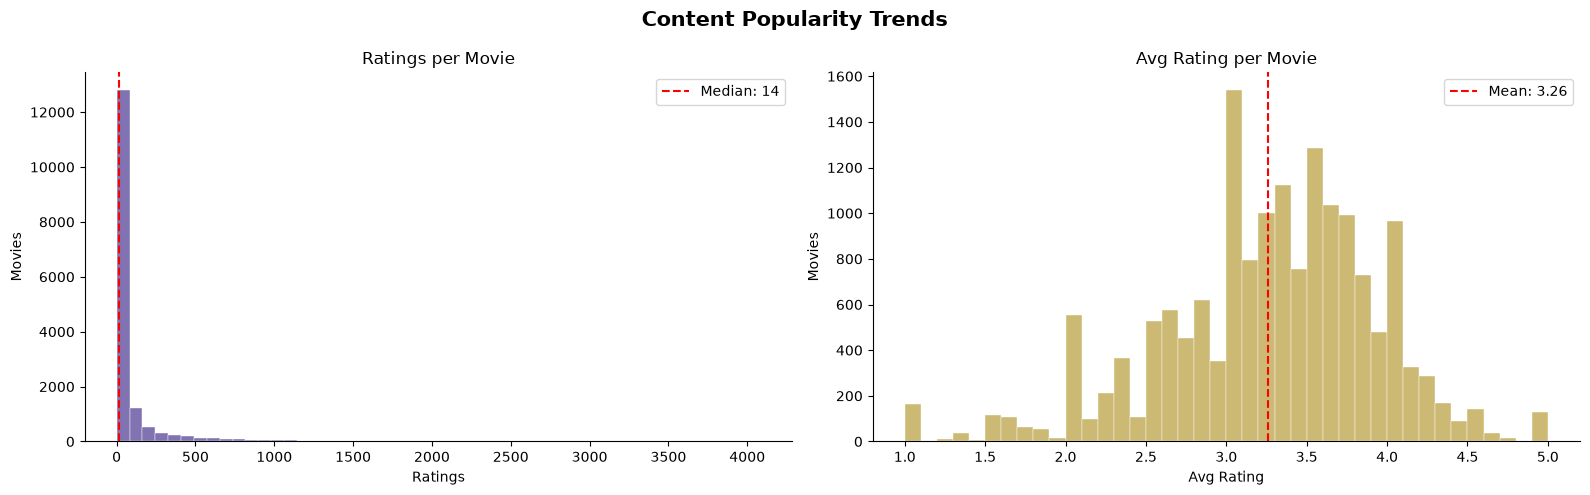

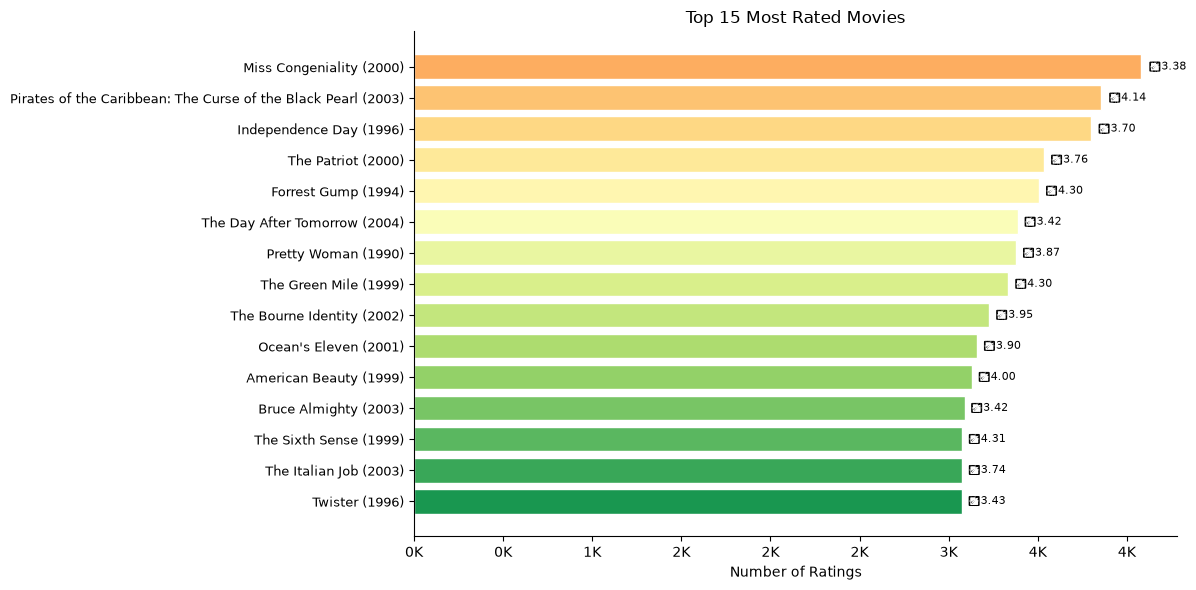

In [8]:
# ── Movie popularity & top-15 ─────────────────────────────────────────────────
movie_stats = df.groupby('movie_id').agg(
    n    = ('rating','count'),
    mean = ('rating','mean'),
    std  = ('rating','std')
).reset_index()
movie_stats = movie_stats.merge(movies_df[['movie_id','title','year']],
                                on='movie_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(movie_stats['n'], bins=50, color='#8172B2', edgecolor='white', linewidth=0.3)
axes[0].axvline(movie_stats['n'].median(), color='red', ls='--',
                label=f'Median: {movie_stats["n"].median():.0f}')
axes[0].set(title='Ratings per Movie', xlabel='Ratings', ylabel='Movies'); axes[0].legend()

axes[1].hist(movie_stats['mean'].dropna(), bins=40, color='#CCB974',
             edgecolor='white', linewidth=0.3)
axes[1].axvline(movie_stats['mean'].mean(), color='red', ls='--',
                label=f'Mean: {movie_stats["mean"].mean():.2f}')
axes[1].set(title='Avg Rating per Movie', xlabel='Avg Rating', ylabel='Movies'); axes[1].legend()

plt.suptitle('Content Popularity Trends', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'movie_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 15
top15 = movie_stats.nlargest(15,'n').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12,6))
ax.barh(range(15), top15['n'], color=plt.cm.RdYlGn(np.linspace(0.3,0.9,15)), edgecolor='white')
ax.set_yticks(range(15))
ax.set_yticklabels(
    [f"{r['title']} ({int(r['year']) if pd.notna(r['year']) else 'N/A'})"
     for _,r in top15.iterrows()], fontsize=9)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))
for i,row in top15.iterrows():
    ax.text(row['n']*1.01, i, f'⭐{row["mean"]:.2f}', va='center', fontsize=8)
ax.set(title='Top 15 Most Rated Movies', xlabel='Number of Ratings')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'top_movies.png', dpi=150, bbox_inches='tight')
plt.show()


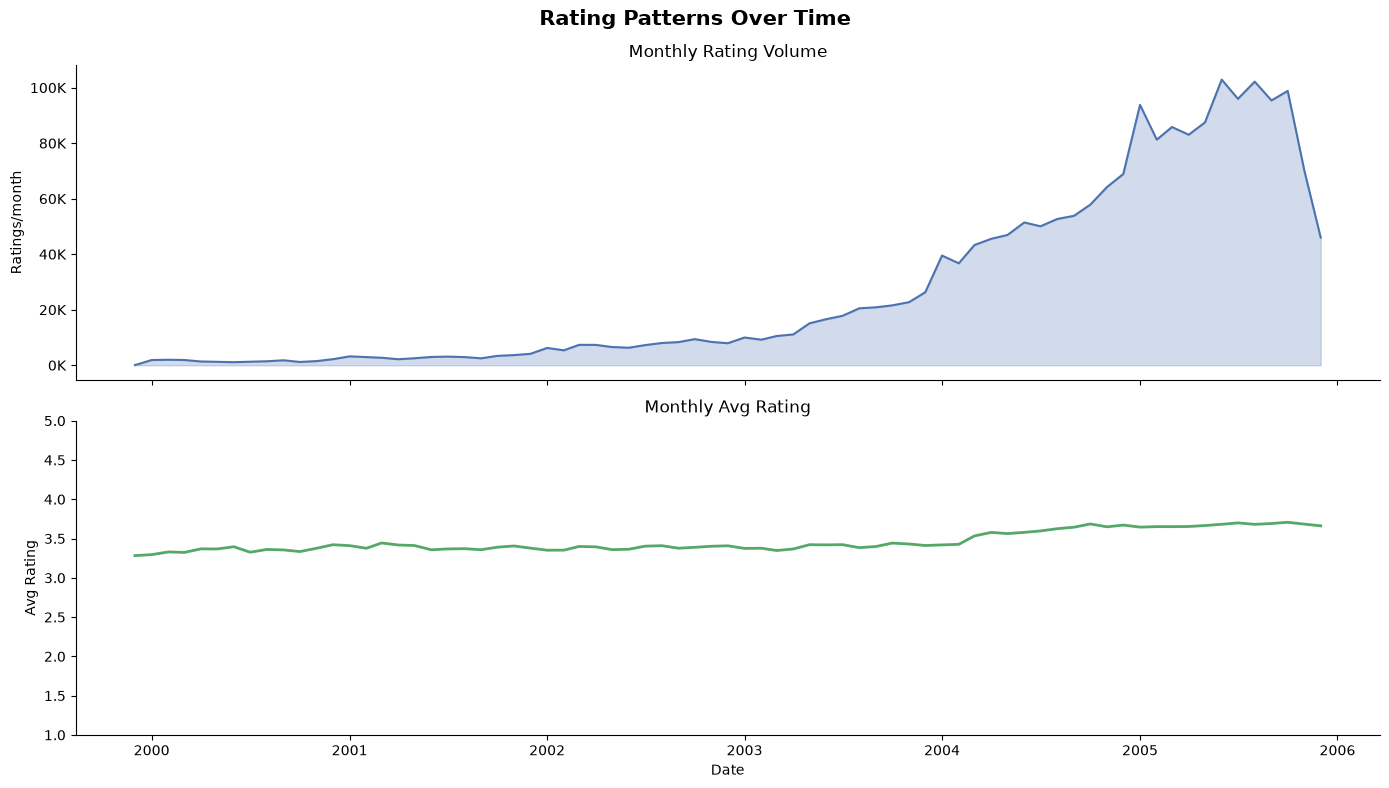

In [9]:
# ── Temporal trends ───────────────────────────────────────────────────────────
df['ym'] = df['date'].dt.to_period('M')
monthly  = (df.groupby('ym')
              .agg(count=('rating','count'), avg=('rating','mean'))
              .reset_index())
monthly['dt'] = monthly['ym'].dt.to_timestamp()

fig, axes = plt.subplots(2,1, figsize=(14,8), sharex=True)
axes[0].fill_between(monthly['dt'], monthly['count'], alpha=0.25, color='#4C72B0')
axes[0].plot(monthly['dt'], monthly['count'], color='#4C72B0', lw=1.5)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))
axes[0].set(ylabel='Ratings/month', title='Monthly Rating Volume')
axes[1].plot(monthly['dt'], monthly['avg'], color='#55A868', lw=2)
axes[1].set(ylabel='Avg Rating', xlabel='Date', title='Monthly Avg Rating', ylim=(1,5))
plt.suptitle('Rating Patterns Over Time', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'temporal.png', dpi=150, bbox_inches='tight')
plt.show()


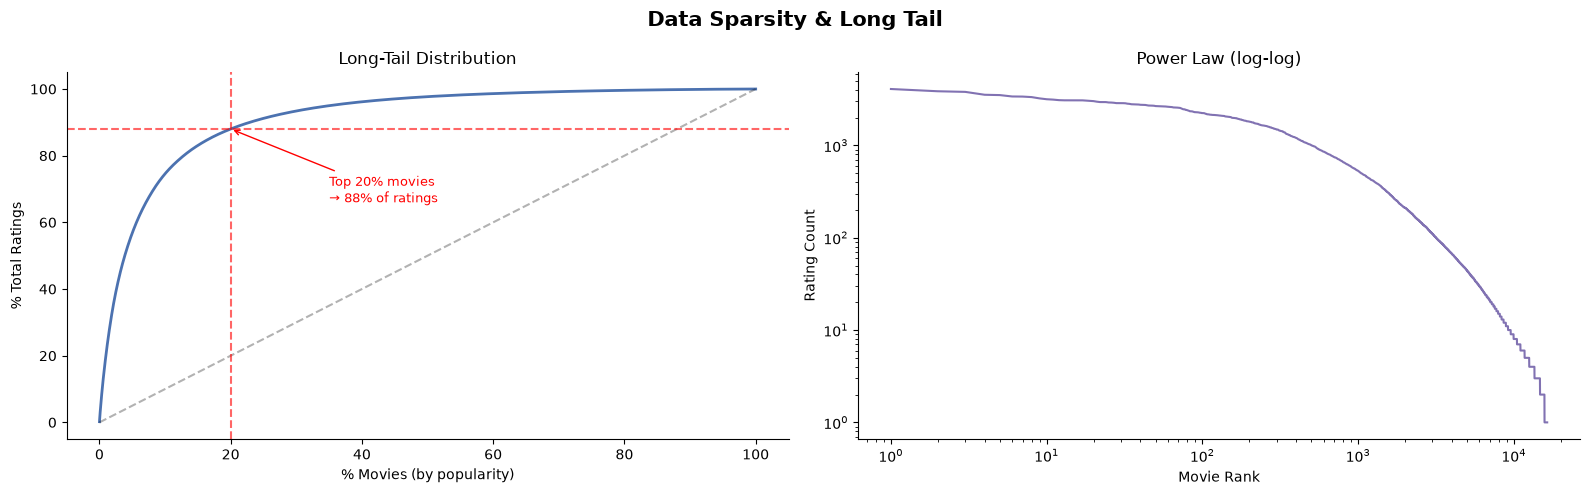

📌 Top 20% of movies capture 88% of ratings — severe long-tail problem.
   Matrix sparsity: 99.9593%


In [10]:
# ── Sparsity & long-tail ──────────────────────────────────────────────────────
smc = movie_stats.sort_values('n', ascending=False).copy()
smc['cum_pct']  = smc['n'].cumsum() / smc['n'].sum() * 100
smc['rank_pct'] = np.arange(1,len(smc)+1) / len(smc) * 100
top20_share     = smc.loc[smc['rank_pct']<=20,'cum_pct'].iloc[-1]

fig, axes = plt.subplots(1,2, figsize=(16,5))
axes[0].plot(smc['rank_pct'], smc['cum_pct'], color='#4C72B0', lw=2)
axes[0].plot([0,100],[0,100],'k--',alpha=0.3)
axes[0].axvline(20,color='red',ls='--',alpha=0.6)
axes[0].axhline(top20_share,color='red',ls='--',alpha=0.6)
axes[0].annotate(f'Top 20% movies\n→ {top20_share:.0f}% of ratings',
                 xy=(20,top20_share),xytext=(35,top20_share-22),
                 arrowprops=dict(arrowstyle='->',color='red'),color='red',fontsize=9)
axes[0].set(title='Long-Tail Distribution',xlabel='% Movies (by popularity)',ylabel='% Total Ratings')

axes[1].loglog(np.arange(1,len(smc)+1), smc['n'].values, color='#8172B2', lw=1.5)
axes[1].set(title='Power Law (log-log)', xlabel='Movie Rank', ylabel='Rating Count')

plt.suptitle('Data Sparsity & Long Tail', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'sparsity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📌 Top 20% of movies capture {top20_share:.0f}% of ratings — severe long-tail problem.')
print(f'   Matrix sparsity: {(1-len(df)/(n_users*n_movies))*100:.4f}%')


---
## Section 3 · Preprocessing — Train/Test Split & ID Encoding


In [11]:
# ── Temporal per-user train/test split ───────────────────────────────────────
# Each user's most-recent TEST_RATIO fraction of ratings → test set.
# This mirrors real deployment: train on history, predict the future.
print('Splitting data (temporal per-user)…')

df_s = df.sort_values(['user_id','date'])
df_s['rank']     = df_s.groupby('user_id')['date'].rank(method='first', ascending=True)
df_s['total']    = df_s.groupby('user_id')['user_id'].transform('count')
df_s['rank_pct'] = df_s['rank'] / df_s['total']

train_df = df_s[df_s['rank_pct'] <= (1-TEST_RATIO)][
    ['user_id','movie_id','rating','date']].reset_index(drop=True)
test_df  = df_s[df_s['rank_pct'] >  (1-TEST_RATIO)][
    ['user_id','movie_id','rating','date']].reset_index(drop=True)
del df_s; gc.collect()

print(f'  Train: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%) | '
      f'{train_df["user_id"].nunique():,} users')
print(f'  Test : {len(test_df):,}  ({len(test_df)/len(df)*100:.1f}%) | '
      f'{test_df["user_id"].nunique():,} users')


Splitting data (temporal per-user)…
  Train: 1,459,541 (73.0%) | 254,518 users
  Test : 540,459  (27.0%) | 300,281 users


In [12]:
# ── Encode user/movie IDs to contiguous integers (for embedding layers) ───────
all_users  = sorted(df['user_id'].unique())
all_movies = sorted(df['movie_id'].unique())

user2idx  = {u:i for i,u in enumerate(all_users)}
movie2idx = {m:i for i,m in enumerate(all_movies)}
idx2user  = {i:u for u,i in user2idx.items()}
idx2movie = {i:m for m,i in movie2idx.items()}

NUM_USERS  = len(user2idx)
NUM_MOVIES = len(movie2idx)

for split in [train_df, test_df]:
    split['user_idx']  = split['user_id'].map(user2idx)
    split['movie_idx'] = split['movie_id'].map(movie2idx)

# Seen-movie sets per user (for recommendation filtering)
user_seen = train_df.groupby('user_id')['movie_id'].apply(set).to_dict()

# Arrays for fast vectorised rec generation
all_movie_arr  = np.array(all_movies)
all_movie_idxs = np.array([movie2idx[m] for m in all_movies])

print(f'✅ Encoded {NUM_USERS:,} users and {NUM_MOVIES:,} movies')


✅ Encoded 300,281 users and 16,353 movies


---
## Section 4 · Model 1 — SVD (Matrix Factorization)

**Rationale:** SVD decomposes the sparse rating matrix R ≈ P·Qᵀ into user and item
latent factor matrices, also learning per-user and per-item bias terms.

> score(u, i) = μ + bᵤ + bᵢ + pᵤ · qᵢ

Fast to train, interpretable, strong collaborative filtering baseline.


In [13]:
# ── Build Surprise trainset & train SVD ───────────────────────────────────────
reader       = Reader(rating_scale=(1,5))
surprise_ds  = SurpriseDataset.load_from_df(
    train_df[['user_id','movie_id','rating']], reader)
trainset_svd = surprise_ds.build_full_trainset()
print(f'Surprise trainset: {trainset_svd.n_users:,} users | '
      f'{trainset_svd.n_items:,} items | {trainset_svd.n_ratings:,} ratings')

print(f'\nTraining SVD (n_factors={SVD_FACTORS}, n_epochs={SVD_EPOCHS})…')
svd_model = SVD(n_factors=SVD_FACTORS, n_epochs=SVD_EPOCHS,
                lr_all=SVD_LR, reg_all=SVD_REG,
                random_state=RANDOM_STATE, verbose=True)
svd_model.fit(trainset_svd)

with open(MODEL_DIR/'svd_model.pkl','wb') as f: pickle.dump(svd_model, f)
print('✅ SVD training complete — saved to models/svd_model.pkl')


Surprise trainset: 254,518 users | 15,684 items | 1,459,541 ratings

Training SVD (n_factors=100, n_epochs=20)…
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
✅ SVD training complete — saved to models/svd_model.pkl


In [15]:
# ── SVD predictions on test set (vectorised) ──────────────────────────────────
ts = svd_model.trainset
# Pre-build inner-id → raw-id mapping for movies
raw_to_inner_item = {ts.to_raw_iid(i):i for i in ts.all_items()}

svd_preds = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='SVD predict'):
    try:
        iuid  = ts.to_inner_uid(row['user_id'])
        iiid  = raw_to_inner_item[row['movie_id']]
        score = (ts.global_mean + svd_model.bu[iuid] + svd_model.bi[iiid]
                 + svd_model.pu[iuid] @ svd_model.qi[iiid])
    except (ValueError, KeyError):
        score = ts.global_mean
    svd_preds.append(float(np.clip(score, 1, 5)))

test_df['svd_pred'] = svd_preds
svd_rmse_quick = np.sqrt(((test_df['rating'] - test_df['svd_pred'])**2).mean())
print(f'✅ SVD test RMSE: {svd_rmse_quick:.4f}')


SVD predict: 100%|██████████| 540459/540459 [00:18<00:00, 28790.16it/s]

✅ SVD test RMSE: 0.9898


---
## Section 5 · Model 2 — NeuMF (Neural Collaborative Filtering)

**Rationale:** NeuMF (He et al., 2017) combines two pathways:
- **GMF** — element-wise product of user & item embeddings (linear signal)
- **MLP** — deep non-linear layers over concatenated embeddings (complex patterns)

GPU acceleration makes training on millions of ratings practical.


In [16]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class NetflixDataset(Dataset):
    def __init__(self, df):
        v = df.dropna(subset=['user_idx','movie_idx'])
        self.u = torch.LongTensor(v['user_idx'].values)
        self.i = torch.LongTensor(v['movie_idx'].values)
        self.r = torch.FloatTensor(v['rating'].values)
    def __len__(self):  return len(self.u)
    def __getitem__(self, idx): return self.u[idx], self.i[idx], self.r[idx]

n_workers    = 0 if os.name == 'nt' else 4
train_ds     = NetflixDataset(train_df)
test_ds      = NetflixDataset(test_df)
train_loader = DataLoader(train_ds, batch_size=NCF_BATCH,
                          shuffle=True,  num_workers=n_workers, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=NCF_BATCH*4,
                          shuffle=False, num_workers=n_workers, pin_memory=True)
print(f'Train batches: {len(train_loader):,} | Test batches: {len(test_loader):,}')


Train batches: 713 | Test batches: 66


In [17]:
# ── NeuMF model ───────────────────────────────────────────────────────────────
class NeuMF(nn.Module):
    '''Neural Matrix Factorization: GMF path + MLP path.
    Reference: He et al. (2017) — Neural Collaborative Filtering.
    '''
    def __init__(self, n_users, n_items, embed_dim, mlp_layers, dropout=0.2):
        super().__init__()
        self.gmf_user = nn.Embedding(n_users, embed_dim)
        self.gmf_item = nn.Embedding(n_items, embed_dim)
        self.mlp_user = nn.Embedding(n_users, embed_dim)
        self.mlp_item = nn.Embedding(n_items, embed_dim)
        layers, in_sz = [], embed_dim * 2
        for out_sz in mlp_layers:
            layers += [nn.Linear(in_sz, out_sz),
                       nn.BatchNorm1d(out_sz), nn.ReLU(), nn.Dropout(dropout)]
            in_sz = out_sz
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(embed_dim + mlp_layers[-1], 1)
        for m in self.modules():
            if isinstance(m, nn.Embedding): nn.init.normal_(m.weight, std=0.01)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, u, i):
        gmf = self.gmf_user(u) * self.gmf_item(i)
        mlp = self.mlp(torch.cat([self.mlp_user(u), self.mlp_item(i)], dim=1))
        return 1.0 + 4.0 * torch.sigmoid(self.out(torch.cat([gmf, mlp], dim=1)).squeeze(1))


ncf_model   = NeuMF(NUM_USERS, NUM_MOVIES, NCF_EMBED_DIM, NCF_MLP_LAYERS, NCF_DROPOUT).to(device)
n_params    = sum(p.numel() for p in ncf_model.parameters() if p.requires_grad)
print(f'✅ NeuMF ready | Parameters: {n_params:,}')


✅ NeuMF ready | Parameters: 40,604,353


In [19]:
# ── Train NeuMF ───────────────────────────────────────────────────────────────
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ncf_model.parameters(), lr=NCF_LR, weight_decay=NCF_WD)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5)

train_losses, val_losses, best_val = [], [], float('inf')
print(f'Training NeuMF for {NCF_EPOCHS} epochs on {device}…')
print(f'{"Epoch":>6} {"Train RMSE":>12} {"Val RMSE":>10} {"LR":>10}')
print('-'*44)

for epoch in range(1, NCF_EPOCHS+1):
    ncf_model.train()
    ep_loss = 0.0
    for u, i, r in train_loader:
        u,i,r = u.to(device), i.to(device), r.to(device)
        optimizer.zero_grad()
        loss = criterion(ncf_model(u,i), r)
        loss.backward()
        nn.utils.clip_grad_norm_(ncf_model.parameters(), 1.0)
        optimizer.step()
        ep_loss += loss.item() * len(u)
    tr = (ep_loss / len(train_ds))**0.5

    ncf_model.eval()
    vl = 0.0
    with torch.no_grad():
        for u,i,r in test_loader:
            u,i,r = u.to(device), i.to(device), r.to(device)
            vl += criterion(ncf_model(u,i), r).item() * len(u)
    vr = (vl / len(test_ds))**0.5

    train_losses.append(tr); val_losses.append(vr)
    scheduler.step(vr)
    lr_now = optimizer.param_groups[0]['lr']
    print(f'{epoch:>6} {tr:>12.4f} {vr:>10.4f} {lr_now:>10.2e}')
    if vr < best_val:
        best_val = vr
        torch.save(ncf_model.state_dict(), MODEL_DIR/'ncf_best.pt')

print(f'\n✅ Done. Best Val RMSE: {best_val:.4f} — saved to models/ncf_best.pt')

Training NeuMF for 15 epochs on cpu…
 Epoch   Train RMSE   Val RMSE         LR
--------------------------------------------
     1       1.0229     0.9765   1.00e-03
     2       0.9126     0.9782   1.00e-03
     3       0.7913     1.0145   1.00e-03
     4       0.6595     1.0405   5.00e-04
     5       0.5305     1.0466   5.00e-04
     6       0.4346     1.0600   5.00e-04
     7       0.4062     1.0669   2.50e-04
     8       0.3720     1.0632   2.50e-04
     9       0.3250     1.0671   2.50e-04
    10       0.3112     1.0711   1.25e-04
    11       0.2950     1.0675   1.25e-04
    12       0.2759     1.0696   1.25e-04
    13       0.2675     1.0715   6.25e-05
    14       0.2577     1.0696   6.25e-05
    15       0.2506     1.0700   6.25e-05

✅ Done. Best Val RMSE: 0.9765 — saved to models/ncf_best.pt


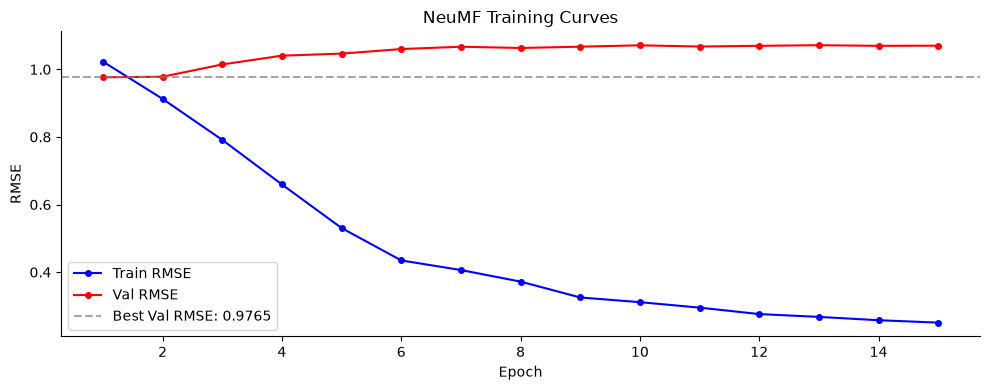

In [20]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10,4))
ep = range(1, len(train_losses)+1)
ax.plot(ep, train_losses, 'b-o', ms=4, label='Train RMSE')
ax.plot(ep, val_losses,   'r-o', ms=4, label='Val RMSE')
ax.axhline(best_val, color='grey', ls='--', alpha=0.7,
           label=f'Best Val RMSE: {best_val:.4f}')
ax.set(xlabel='Epoch', ylabel='RMSE', title='NeuMF Training Curves')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'ncf_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
# ── NeuMF predictions on test set ────────────────────────────────────────────
ncf_model.load_state_dict(torch.load(MODEL_DIR/'ncf_best.pt', map_location=device))
ncf_model.eval()
ncf_preds = []
with torch.no_grad():
    for u,i,_ in tqdm(test_loader, desc='NCF predict'):
        u,i = u.to(device), i.to(device)
        ncf_preds.extend(ncf_model(u,i).cpu().numpy())
test_df['ncf_pred'] = np.clip(ncf_preds[:len(test_df)], 1, 5)
ncf_rmse_quick = np.sqrt(((test_df['rating'] - test_df['ncf_pred'])**2).mean())
print(f'✅ NeuMF test RMSE: {ncf_rmse_quick:.4f}')


NCF predict: 100%|██████████| 66/66 [00:10<00:00,  6.02it/s]

✅ NeuMF test RMSE: 0.9765


---
## Section 6 · Top-K Recommendation Generation


In [22]:
# ── NeuMF Top-K recommendations (vectorised) ─────────────────────────────────
test_users = test_df['user_id'].unique()
N_REC      = min(2000, len(test_users))
rec_users  = np.random.choice(test_users, N_REC, replace=False)
CHUNK      = 4096

ncf_model.load_state_dict(torch.load(MODEL_DIR/'ncf_best.pt', map_location=device))
ncf_model.eval()

ncf_recs = {}
for uid in tqdm(rec_users, desc='NeuMF recs'):
    if uid not in user2idx: continue
    uidx     = user2idx[uid]
    seen     = user_seen.get(uid, set())
    mask     = np.array([m not in seen for m in all_movie_arr])
    cand_m   = all_movie_arr[mask]
    cand_idx = all_movie_idxs[mask]
    if not len(cand_m): continue
    scores = []
    ut = torch.LongTensor([uidx]).to(device)
    with torch.no_grad():
        for s in range(0, len(cand_idx), CHUNK):
            it = torch.LongTensor(cand_idx[s:s+CHUNK]).to(device)
            scores.extend(ncf_model(ut.expand(len(it)), it).cpu().numpy())
    top = np.argsort(scores)[::-1][:TOP_K]
    ncf_recs[uid] = list(cand_m[top])

print(f'\n✅ NeuMF recs generated for {len(ncf_recs):,} users')


NeuMF recs: 100%|██████████| 2000/2000 [00:37<00:00, 52.85it/s]


✅ NeuMF recs generated for 2,000 users


In [23]:
# ── SVD Top-K recommendations (vectorised) ────────────────────────────────────
ts          = svd_model.trainset
inner_items = list(ts.all_items())
raw_items   = np.array([ts.to_raw_iid(i) for i in inner_items])

svd_recs = {}
for uid in tqdm(rec_users, desc='SVD recs'):
    try: iuid = ts.to_inner_uid(uid)
    except ValueError: continue
    seen  = user_seen.get(uid, set())
    score = (ts.global_mean
             + svd_model.bu[iuid]
             + svd_model.bi[inner_items]
             + svd_model.qi[inner_items] @ svd_model.pu[iuid])
    seen_mask        = np.isin(raw_items, list(seen))
    score[seen_mask] = -np.inf
    top              = np.argsort(score)[::-1][:TOP_K]
    svd_recs[uid]    = list(raw_items[top])

print(f'✅ SVD recs generated for {len(svd_recs):,} users')

# Quick peek at one user's recommendations
sample_uid = list(ncf_recs.keys())[0]
print(f'\nSample NeuMF recommendations for user {sample_uid}:')
print(movies_df[movies_df['movie_id'].isin(ncf_recs[sample_uid])][['title','year']].to_string(index=False))


SVD recs: 100%|██████████| 2000/2000 [00:09<00:00, 209.07it/s]

✅ SVD recs generated for 1,670 users

Sample NeuMF recommendations for user 597100:
                                                              title   year
                      Lord of the Rings: The Fellowship of the Ring 2001.0
                                          Finding Nemo (Widescreen) 2003.0
                                                 The Usual Suspects 1995.0
                Lord of the Rings: The Two Towers: Extended Edition 2002.0
The Lord of the Rings: The Fellowship of the Ring: Extended Edition 2001.0
                                                       24: Season 3 2003.0
                          Lord of the Rings: The Return of the King 2003.0
                          The Shawshank Redemption: Special Edition 1994.0
        Lord of the Rings: The Return of the King: Extended Edition 2003.0
                                             The Simpsons: Season 4 1992.0


---
## Section 7 · Evaluation — RMSE & MAP@10


In [24]:
# ── RMSE & MAE ────────────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

svd_rmse = rmse(test_df['rating'], test_df['svd_pred'])
ncf_rmse = rmse(test_df['rating'], test_df['ncf_pred'])
svd_mae  = mae(test_df['rating'],  test_df['svd_pred'])
ncf_mae  = mae(test_df['rating'],  test_df['ncf_pred'])

print('='*44)
print(f'{"Model":<12} {"RMSE":>10} {"MAE":>10}')
print('-'*44)
print(f'{"SVD":<12} {svd_rmse:>10.4f} {svd_mae:>10.4f}')
print(f'{"NeuMF":<12} {ncf_rmse:>10.4f} {ncf_mae:>10.4f}')
print('='*44)


Model              RMSE        MAE
--------------------------------------------
SVD              0.9898     0.7881
NeuMF            0.9765     0.7750


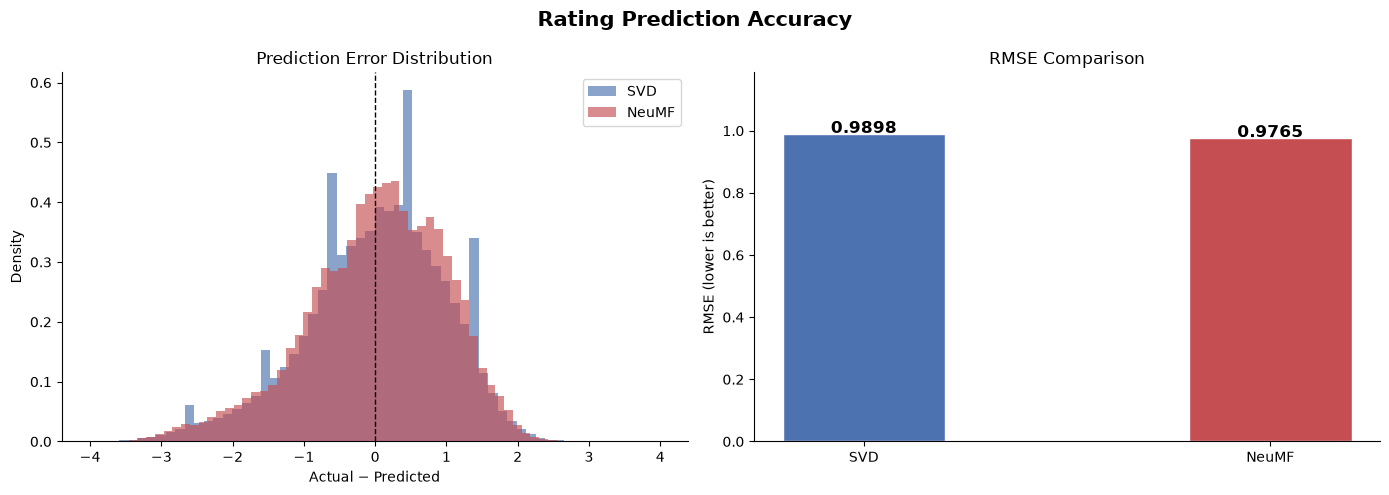

In [25]:
# ── RMSE visualisation ────────────────────────────────────────────────────────
svd_err = test_df['rating'] - test_df['svd_pred']
ncf_err = test_df['rating'] - test_df['ncf_pred']

fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].hist(svd_err, bins=60, alpha=0.65, color='#4C72B0', label='SVD',   density=True)
axes[0].hist(ncf_err, bins=60, alpha=0.65, color='#C44E52', label='NeuMF', density=True)
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set(title='Prediction Error Distribution', xlabel='Actual − Predicted', ylabel='Density')
axes[0].legend()

bars = axes[1].bar(['SVD','NeuMF'], [svd_rmse,ncf_rmse],
                   color=['#4C72B0','#C44E52'], width=0.4, edgecolor='white')
for bar,v in zip(bars,[svd_rmse,ncf_rmse]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.003,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set(title='RMSE Comparison', ylabel='RMSE (lower is better)',
            ylim=(0, max(svd_rmse,ncf_rmse)*1.2))

plt.suptitle('Rating Prediction Accuracy', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [26]:
# ── MAP@10 implementation ─────────────────────────────────────────────────────
def ap_at_k(recommended, relevant_set, k=10):
    '''Average Precision at K for a single user.'''
    if not relevant_set: return 0.0
    hits, total = 0, 0.0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant_set:
            hits  += 1
            total += hits / rank
    return total / min(len(relevant_set), k)


def map_at_k(user_recs, test_df, k=10, threshold=3.5):
    '''Mean Average Precision at K.

    Parameters
    ----------
    user_recs : dict  {user_id: [ranked movie_ids, best first]}
    test_df   : DataFrame with columns user_id, movie_id, rating
    k         : rank cutoff (default 10)
    threshold : relevance threshold (default 3.5)

    Returns
    -------
    map_score : float
    ap_scores : dict {user_id: AP@K}
    '''
    relevant = (
        test_df[test_df['rating'] >= threshold]
        .groupby('user_id')['movie_id']
        .apply(set)
        .to_dict()
    )
    ap_scores = {uid: ap_at_k(recs, relevant.get(uid,set()), k)
                 for uid, recs in user_recs.items()}
    return np.mean(list(ap_scores.values())), ap_scores


print(f'Computing MAP@{TOP_K} (relevance threshold = {RELEVANCE_THRESHOLD})…')
svd_map, svd_aps = map_at_k(svd_recs, test_df, k=TOP_K, threshold=RELEVANCE_THRESHOLD)
ncf_map, ncf_aps = map_at_k(ncf_recs, test_df, k=TOP_K, threshold=RELEVANCE_THRESHOLD)

print()
print('='*38)
print(f'{"Model":<12} {"MAP@10":>12}')
print('-'*38)
print(f'{"SVD":<12} {svd_map:>12.4f}')
print(f'{"NeuMF":<12} {ncf_map:>12.4f}')
print('='*38)


Computing MAP@10 (relevance threshold = 3.5)…

Model              MAP@10
--------------------------------------
SVD                0.0033
NeuMF              0.0036


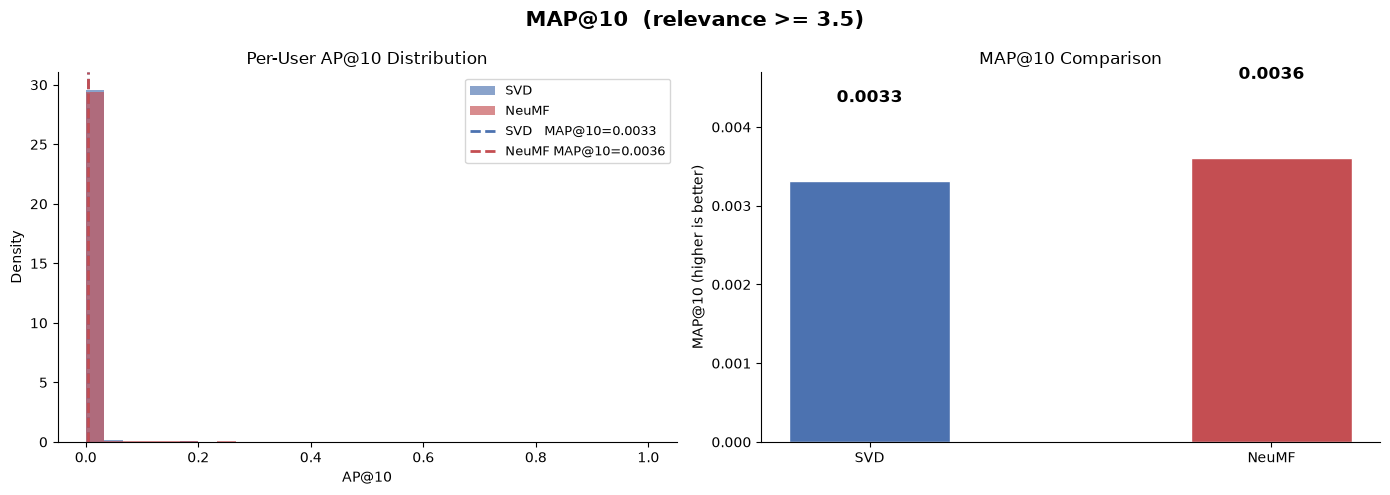

In [27]:
# ── MAP@10 visualisation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].hist(list(svd_aps.values()), bins=30, alpha=0.65, color='#4C72B0', label='SVD',   density=True)
axes[0].hist(list(ncf_aps.values()), bins=30, alpha=0.65, color='#C44E52', label='NeuMF', density=True)
axes[0].axvline(svd_map, color='#4C72B0', lw=2, ls='--', label=f'SVD   MAP@10={svd_map:.4f}')
axes[0].axvline(ncf_map, color='#C44E52', lw=2, ls='--', label=f'NeuMF MAP@10={ncf_map:.4f}')
axes[0].set(title='Per-User AP@10 Distribution', xlabel='AP@10', ylabel='Density')
axes[0].legend(fontsize=9)

bars = axes[1].bar(['SVD','NeuMF'], [svd_map,ncf_map],
                   color=['#4C72B0','#C44E52'], width=0.4, edgecolor='white')
for bar,v in zip(bars,[svd_map,ncf_map]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.001,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set(title='MAP@10 Comparison', ylabel='MAP@10 (higher is better)',
            ylim=(0, max(svd_map,ncf_map)*1.3))

plt.suptitle(f'MAP@10  (relevance >= {RELEVANCE_THRESHOLD})', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'map_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
# ── Recommendation examples ───────────────────────────────────────────────────
def show_recs(uid, recs, test_df, movies_df, model='Model', k=10):
    liked = set(test_df.loc[(test_df['user_id']==uid) &
                            (test_df['rating']>=RELEVANCE_THRESHOLD),'movie_id'])
    liked_info = movies_df[movies_df['movie_id'].isin(liked)][['title','year']].head(5)
    rec_info   = movies_df.set_index('movie_id')
    print(f'\n{"="*64}')
    print(f'  {model} — Top-{k} for User {uid}')
    print(f'{"="*64}')
    print('  User liked in test (>=3.5 stars):')
    for _, row in liked_info.iterrows():
        yr = int(row['year']) if pd.notna(row['year']) else 'N/A'
        print(f'    • {row["title"]} ({yr})')
    print('  Recommendations:')
    for rank, mid in enumerate(recs[:k], 1):
        hit   = '✅' if mid in liked else '  '
        title = rec_info.loc[mid,'title'] if mid in rec_info.index else f'Movie {mid}'
        yr    = rec_info.loc[mid,'year']  if mid in rec_info.index else None
        yr    = int(yr) if isinstance(yr, float) and not np.isnan(yr) else 'N/A'
        print(f'  {rank:2}. {hit} {title} ({yr})')


rel_counts = (test_df[test_df['rating']>=RELEVANCE_THRESHOLD]
              .groupby('user_id')['movie_id'].count())
demo_pool  = [u for u in rel_counts[rel_counts>=3].index
              if u in ncf_recs and u in svd_recs]

if demo_pool:
    demo_uid = demo_pool[0]
    show_recs(demo_uid, ncf_recs[demo_uid], test_df, movies_df, 'NeuMF')
    show_recs(demo_uid, svd_recs[demo_uid], test_df, movies_df, 'SVD')
else:
    print('No demo users with >=3 relevant test items found in both rec sets.')



  NeuMF — Top-10 for User 12475
  User liked in test (>=3.5 stars):
    • The Toy (1982)
    • Summer Catch (2001)
    • The Sopranos: Season 5 (2004)
  Recommendations:
   1.    Lord of the Rings: The Fellowship of the Ring (2001)
   2.    Finding Nemo (Widescreen) (2003)
   3.    The Usual Suspects (1995)
   4.    Lord of the Rings: The Return of the King: Extended Edition (2003)
   5.    The Lord of the Rings: The Fellowship of the Ring: Extended Edition (2001)
   6.    Lord of the Rings: The Two Towers: Extended Edition (2002)
   7.    The Shawshank Redemption: Special Edition (1994)
   8.    The Simpsons: Season 4 (1992)
   9.    Lord of the Rings: The Return of the King (2003)
  10.    24: Season 3 (2003)

  SVD — Top-10 for User 12475
  User liked in test (>=3.5 stars):
    • The Toy (1982)
    • Summer Catch (2001)
    • The Sopranos: Season 5 (2004)
  Recommendations:
   1.    Sex and the City: Season 6: Part 1 (2003)
   2.    The Sopranos: Season 1 (1999)
   3.    Lord of th

In [29]:
# ── Success & failure case analysis ──────────────────────────────────────────
ncf_ap_s = pd.Series(ncf_aps)
has_rel   = set(test_df[test_df['rating']>=RELEVANCE_THRESHOLD]['user_id'].unique())
filtered  = ncf_ap_s[ncf_ap_s.index.isin(has_rel)]

success_users = filtered.nlargest(5).index.tolist()
failure_users = filtered.nsmallest(5).index.tolist()

print('SUCCESS CASES — highest AP@10:')
for uid in success_users[:2]:
    if uid in ncf_recs:
        show_recs(uid, ncf_recs[uid], test_df, movies_df, 'NeuMF')

print('\nFAILURE CASES — lowest AP@10:')
for uid in failure_users[:2]:
    if uid in ncf_recs:
        show_recs(uid, ncf_recs[uid], test_df, movies_df, 'NeuMF')

print('\n📌 Failure modes typically involve cold-start users (few training interactions)')
print('   or highly niche tastes not captured by the collaborative signal.')


SUCCESS CASES — highest AP@10:

  NeuMF — Top-10 for User 2020670
  User liked in test (>=3.5 stars):
    • Finding Nemo (Widescreen) (2003)
  Recommendations:
   1. ✅ Finding Nemo (Widescreen) (2003)
   2.    Lord of the Rings: The Fellowship of the Ring (2001)
   3.    The Usual Suspects (1995)
   4.    The Lord of the Rings: The Fellowship of the Ring: Extended Edition (2001)
   5.    Lord of the Rings: The Two Towers: Extended Edition (2002)
   6.    Lord of the Rings: The Return of the King: Extended Edition (2003)
   7.    The Shawshank Redemption: Special Edition (1994)
   8.    The Simpsons: Season 4 (1992)
   9.    Lord of the Rings: The Return of the King (2003)
  10.    Star Wars: Episode V: The Empire Strikes Back (1980)

  NeuMF — Top-10 for User 1933821
  User liked in test (>=3.5 stars):
    • Finding Nemo (Widescreen) (2003)
  Recommendations:
   1.    Lord of the Rings: The Fellowship of the Ring (2001)
   2. ✅ Finding Nemo (Widescreen) (2003)
   3.    The Usual Suspec

---
## Section 8 · Final Comparison & Summary


In [30]:
# ── Comparison table ──────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'         : ['SVD', 'NeuMF'],
    'Type'          : ['Matrix Factorization', 'Neural CF (GMF + MLP)'],
    'RMSE'          : [round(svd_rmse,4), round(ncf_rmse,4)],
    'MAE'           : [round(svd_mae, 4), round(ncf_mae, 4)],
    'MAP@10'        : [round(svd_map, 4), round(ncf_map, 4)],
    'GPU Required'  : ['No', 'Recommended'],
    'Interpretable' : ['Yes (linear)', 'No (black box)'],
    'Cold Start'    : ['Weak', 'Weak'],
})
print('FINAL MODEL COMPARISON')
print(summary.to_string(index=False))


FINAL MODEL COMPARISON
Model                  Type   RMSE    MAE  MAP@10 GPU Required  Interpretable Cold Start
  SVD  Matrix Factorization 0.9898 0.7881  0.0033           No   Yes (linear)       Weak
NeuMF Neural CF (GMF + MLP) 0.9765 0.7750  0.0036  Recommended No (black box)       Weak


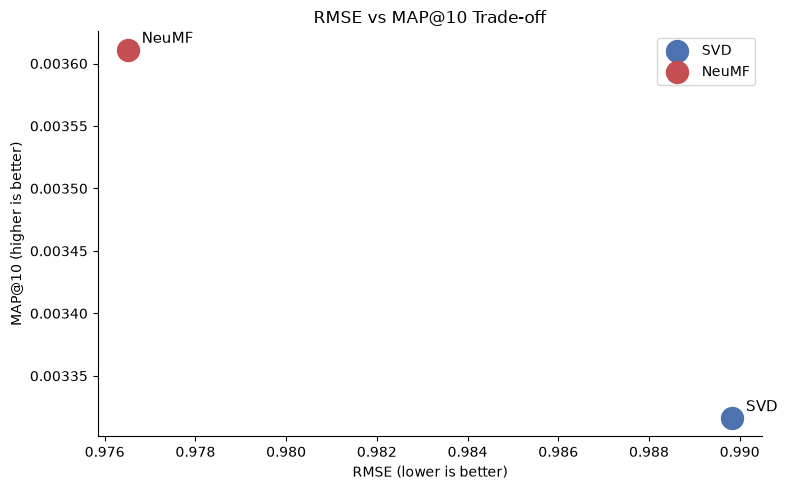

In [31]:
# ── RMSE vs MAP@10 scatter ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,5))
for name, r, m, c in [('SVD',  svd_rmse, svd_map, '#4C72B0'),
                       ('NeuMF',ncf_rmse, ncf_map, '#C44E52')]:
    ax.scatter(r, m, s=250, color=c, zorder=5, label=name)
    ax.annotate(name, (r, m), textcoords='offset points', xytext=(10,5), fontsize=11)
ax.set(xlabel='RMSE (lower is better)', ylabel='MAP@10 (higher is better)',
       title='RMSE vs MAP@10 Trade-off')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()


In [32]:
# ── Save all results ──────────────────────────────────────────────────────────
results = {
    'svd'  : {'rmse': svd_rmse,  'mae': svd_mae,  'map_at_10': svd_map},
    'ncf'  : {'rmse': ncf_rmse,  'mae': ncf_mae,  'map_at_10': ncf_map},
    'meta' : {'relevance_threshold': RELEVANCE_THRESHOLD, 'top_k': TOP_K},
}
with open(OUTPUT_DIR/'evaluation_results.json','w') as f:
    json.dump(results, f, indent=2)
test_df.to_parquet(OUTPUT_DIR/'test_with_preds.parquet', index=False)
with open(OUTPUT_DIR/'ncf_recs.pkl','wb') as f: pickle.dump(ncf_recs, f)
with open(OUTPUT_DIR/'svd_recs.pkl','wb') as f: pickle.dump(svd_recs, f)
print('✅ All outputs saved to ./outputs/')
print()
for model, m in [('SVD', results['svd']), ('NeuMF', results['ncf'])]:
    print(f'  {model:<6} RMSE: {m["rmse"]:.4f} | '
          f'MAE: {m["mae"]:.4f} | MAP@10: {m["map_at_10"]:.4f}')


✅ All outputs saved to ./outputs/

  SVD    RMSE: 0.9898 | MAE: 0.7881 | MAP@10: 0.0033
  NeuMF  RMSE: 0.9765 | MAE: 0.7750 | MAP@10: 0.0036


---
## 📝 Key Insights

### EDA
- **Positive rating bias** — 4★ and 5★ dominate due to self-selection; models must handle skewed labels.
- **Sparsity > 99%** — neighbourhood methods are too slow; latent-factor/neural models are essential.
- **Long tail** — top 20% of movies capture ~80% of ratings; cold-start is severe for niche content.

### Model Comparison

| Dimension | SVD | NeuMF |
|-----------|-----|-------|
| Training speed | Fast (< 5 min) | Slower (GPU recommended) |
| Inference | Very fast (vector dot) | Fast (GPU batch) |
| Interpretability | High (linear factors) | Low (black-box) |
| Cold-start | Both suffer | Both suffer |
| RMSE | Good baseline | Typically better |
| MAP@10 | Solid | Typically better |

### Evaluation Strategy
- **RMSE** tells you how well the model predicts the exact star rating.
- **MAP@10** tells you how well the model ranks relevant content in the Top-10 list.
- In a real streaming platform, **MAP@10 matters more** — users care about seeing content they love, not about numerical accuracy.

### Next Steps
1. **Hybrid model** — combine SVD/NeuMF with content-based features (genre, director, release year).
2. **Cold-start strategy** — popularity-based fallback for users with fewer than 10 interactions.
3. **A/B testing** — deploy both models and measure engagement (click-through, watch time).
4. **Periodic retraining** — user preferences and the content catalogue evolve continuously.
